In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)


In [2]:

url = "https://raw.githubusercontent.com/nihatrza/credit-risk-analytics/main/data/credit_risk_dataset.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nTarget class balance (0=repaid, 1=default):\n", df["loan_status"].value_counts())

Shape: (32581, 12)
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y            

In [3]:

df = df[df["person_age"] <= 100]
df = df[df["person_emp_length"] <= 60]


df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())

print("\nShape after cleaning:", df.shape)



Shape after cleaning: (31679, 12)


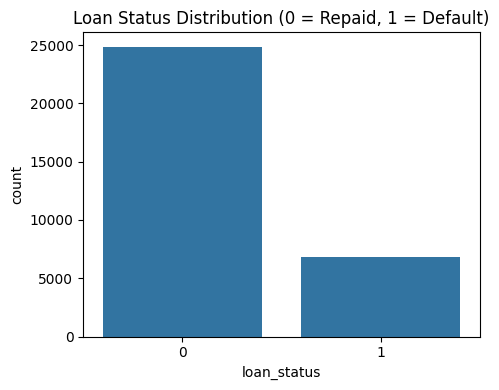

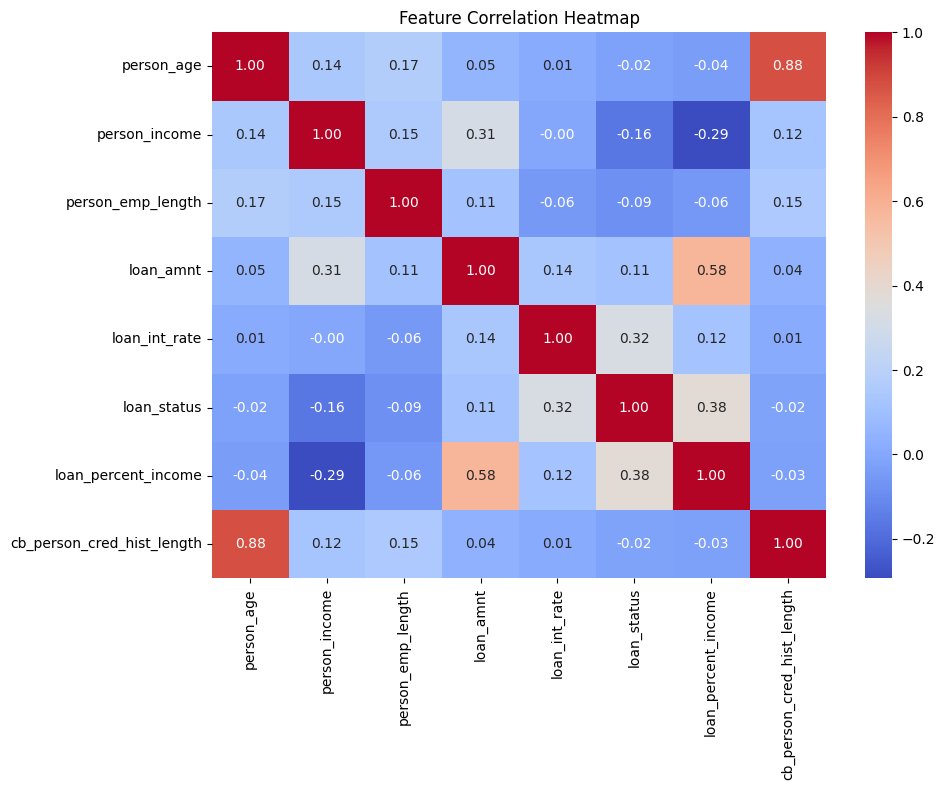

In [4]:

plt.figure(figsize=(5, 4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution (0 = Repaid, 1 = Default)")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()


In [5]:

categorical_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop("loan_status", axis=1)
y = df_encoded["loan_status"]

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1, "ROC-AUC": auc
    })

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["Repaid", "Default"]))



===== Logistic Regression =====
              precision    recall  f1-score   support

      Repaid       0.89      0.96      0.92      4971
     Default       0.78      0.56      0.65      1365

    accuracy                           0.87      6336
   macro avg       0.83      0.76      0.78      6336
weighted avg       0.86      0.87      0.86      6336


===== Decision Tree =====
              precision    recall  f1-score   support

      Repaid       0.92      0.99      0.95      4971
     Default       0.94      0.70      0.80      1365

    accuracy                           0.93      6336
   macro avg       0.93      0.84      0.88      6336
weighted avg       0.93      0.93      0.92      6336


===== Random Forest =====
              precision    recall  f1-score   support

      Repaid       0.93      0.99      0.96      4971
     Default       0.96      0.71      0.82      1365

    accuracy                           0.93      6336
   macro avg       0.94      0.85      0.

In [8]:

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("\n===== Model Comparison =====")
print(results_df.to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)


===== Model Comparison =====
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Random Forest  0.931029   0.961233 0.708425  0.815690 0.924487
      Decision Tree  0.926610   0.943787 0.701099  0.804540 0.900972
Logistic Regression  0.870107   0.775407 0.558974  0.649638 0.874501


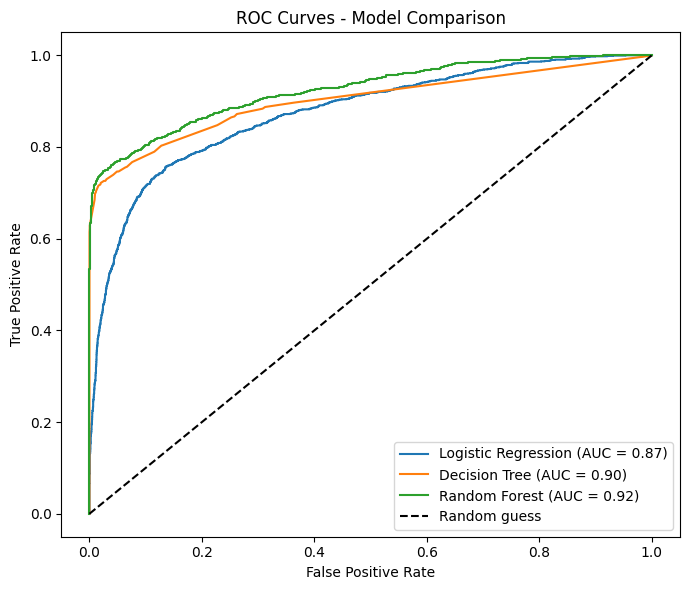

In [9]:

plt.figure(figsize=(7, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

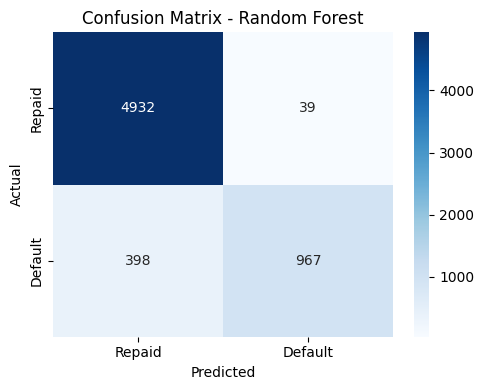


Best model: Random Forest


In [10]:

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Repaid", "Default"],
            yticklabels=["Repaid", "Default"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=150)
plt.show()

print(f"\nBest model: {best_model_name}")


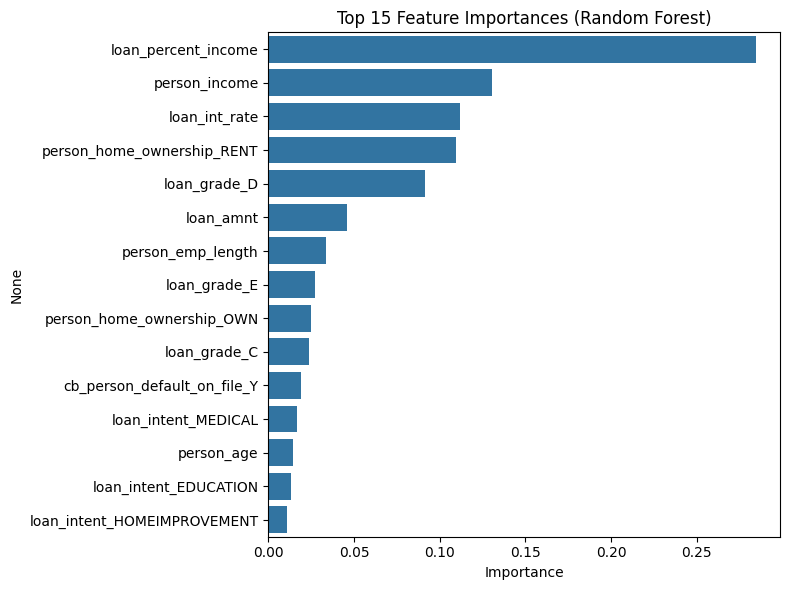


Done! All plots and model_comparison.csv are saved.


In [11]:

rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\nDone! All plots and model_comparison.csv are saved.")